# Soluciones Numericas de EDO


### Forma màs basica : Metodo de Euler 

Ej: si definimos u(t)
\begin{gather}
d²z(t)+w²z(t)=0 \quad u(t)= dz(t) du(t)=d²z(t)=-w²z \\
def: X(t)=[z(t),u(t)] dX=[dz,du]=[u,-w²z]\\
X[0]=z y X[1]=u\\
dX=[X[1]-w²X[0]]
\end{gather}
Dandonos el metodo de euler ocupando la derivada adelanta
\begin{equation}
x(t+h)\simeq x(t)+hf(x(t),t)
\end{equation}

## Ejemplo masa unida a un resorte
\begin{equation}
 x=[y(t),u(t)], \quad f=[u(t),-w²y(t)-g], \quad dx=f(x,t)
\end{equation}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

In [ ]:
h=0.000002
Ntiempo= 40
t = np.arange(0,h*Ntiempo,h)
tt = np.linspace(0,h*Ntiempo,40)

# Metodo de Euler

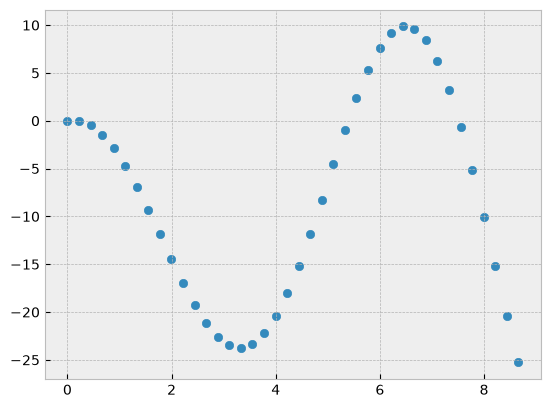

In [ ]:
omega = 1.0
g = 9.8

def f(x, omega, g = 9.8):
    y, u = x 
    return np.array([u,-g-y*omega**2])

x = np.zeros([Ntiempo, 2])
x[0,0] = 0
x[0,1] = 0
h=0.222

for n in range(Ntiempo-1):
    x[n+1] = x[n] + h*f(x[n], omega, g)
y = x[:,0]
u = x[:,1]

plt.scatter(t,y)

## Energia de Metodo de Euler
No conserva la energía por lo que cuanto más tiempo pasa más diferente es a la grafica de la analitica

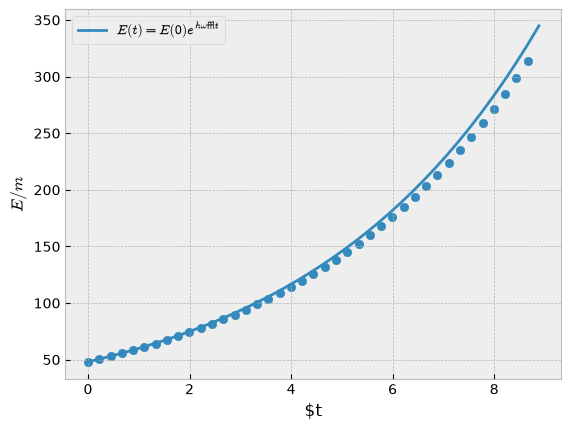

In [4]:
E = u**2/2 + (omega**2/2)*(y+g/omega**2)**2
EE = E[0]*np.exp(omega**2*h*tt)
plt.plot(tt,EE, label='$E(t)=E(0)e^{h\\omega²t}$')
plt.scatter(t,E)
plt.xlabel('$t')
plt.ylabel('$E/m$')
#lt.yscale('log')
plt.legend()

# Metodo de Euler-Cromer

In [5]:
y_EC = np.zeros(Ntiempo)
u_EC = np.zeros(Ntiempo)
y_EC[0] = 0
u_EC[0] = 0

for n in range(Ntiempo-1):
    u_EC[n+1] = u_EC[n] - h*(y_EC[n]*omega**2+g)
    y_EC[n+1] = y_EC[n] + h*u_EC[n+1]


#u[n+1] = u[n]-h*(y[n]*omega**2+g)
#y[n+1] = y[n]+h*u[n+1]

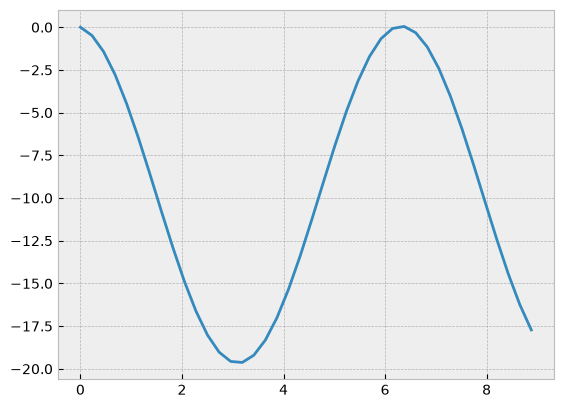

In [6]:
t = np.arange(0,h*Ntiempo)
plt.plot(tt,y_EC)

## Energia del metodo de Euler-Cromer
La energia se conserva de mejor manera

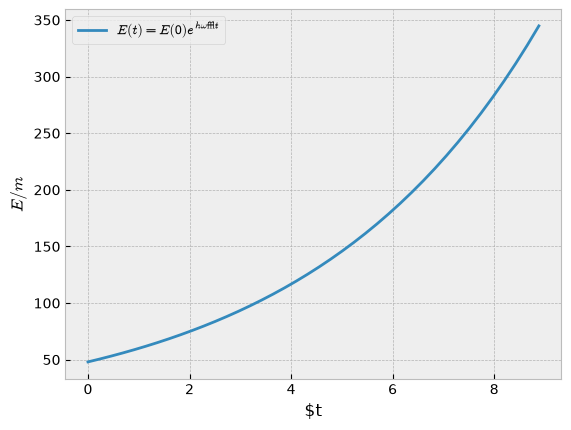

In [9]:
E_EC = u**2/2 + (omega**2/2)*(y+g/omega**2)**2
EE = E[0]*np.exp(omega**2*h*tt)
plt.plot(tt,EE, label='$E(t)=E(0)e^{h\\omega²t}$')
#plt.scatter(tt,E_EC)
plt.xlabel('$t')
plt.ylabel('$E/m$')
#plt.yscale('log')
plt.legend()

# Metodo de Salto de Rana
Ocupamos la derivada centrada con saltos de $1/2$, pero ya que rara vez conocemos la posicion inicial $1/2$ tenemos que empezar el metodo del Salto de Rana con el metodo de Euler

In [18]:
y_SR = np.zeros(Ntiempo)
v_SR = np.zeros(Ntiempo)

y_SR[0] = 0
v_SR[0] = 0 + (h/2)*(-y[0]*omega**2 - g) # v[n] representa a V_1/2
for n in range(Ntiempo-1):
    y_SR[n+1] = y_SR[n] + h*v_SR[n]
    v_SR[n+1] = v_SR[n] + h*(-y_SR[n+1]*omega**2-g)


ValueError: x and y must be the same size

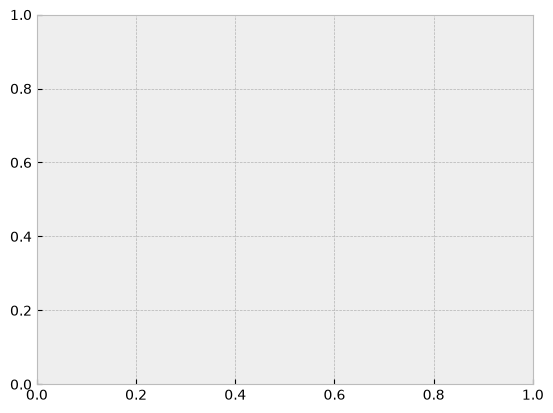

In [19]:
plt.scatter(t,y_SR)